In [ ]:
!pip install scikit-learn scipy -q
print('Зависимости установлены')

Зависимости установлены


In [ ]:
import os

if not os.path.exists('stanford_dogs/Images'):
    print('Скачиваем изображения (~750 МБ)...')
    !wget -q --show-progress http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar

    print('Скачиваем аннотации...')
    !wget -q http://vision.stanford.edu/aditya86/ImageNetDogs/lists.tar

    print('Распаковываем...')
    !tar -xf images.tar
    !tar -xf lists.tar

    print('Содержимое текущей директории после распаковки:')
    print(os.listdir('.'))

    os.makedirs('stanford_dogs', exist_ok=True)

    # Перемещаем папку Images
    if os.path.exists('Images') and not os.path.exists('stanford_dogs/Images'):
        !mv Images stanford_dogs/
        print('Images/ перемещена')

    # Перемещаем .mat файлы аннотаций
    os.makedirs('stanford_dogs/lists', exist_ok=True)
    for mat_file in ['train_list.mat', 'test_list.mat', 'file_list.mat']:
        if os.path.exists(mat_file):
            os.rename(mat_file, f'stanford_dogs/lists/{mat_file}')
            print(f'{mat_file} перемещён')

    # Перемещаем папку lists если она существует
    if os.path.exists('lists') and not os.path.exists('stanford_dogs/lists/train_list.mat'):
        !mv lists stanford_dogs/
        print('lists/ перемещена')

else:
    print('Датасет уже скачан')

# Проверка структуры
print('\nПроверка:')
print('  stanford_dogs/Images:', os.path.exists('stanford_dogs/Images'))
print('  train_list.mat:      ', os.path.exists('stanford_dogs/lists/train_list.mat'))
print('  test_list.mat:       ', os.path.exists('stanford_dogs/lists/test_list.mat'))
breeds = os.listdir('stanford_dogs/Images') if os.path.exists('stanford_dogs/Images') else []
print(f'  Количество пород:    {len(breeds)}')

Скачиваем изображения (~750 МБ)...
images.tar          100%[===================>] 756.82M  11.5MB/s    in 63s     
Скачиваем аннотации...
Распаковываем...
Содержимое текущей директории после распаковки:
['.config', 'file_list.mat', 'images.tar', 'Images', 'test_list.mat', 'lists.tar', 'train_list.mat', 'sample_data']
Images/ перемещена
train_list.mat перемещён
test_list.mat перемещён
file_list.mat перемещён

Проверка:
  stanford_dogs/Images: True
  train_list.mat:       True
  test_list.mat:        True
  Количество пород:    120


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import scipy.io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_fscore_support
import time
import warnings
warnings.filterwarnings('ignore')

# Проверяем доступность GPU
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('GPU не найден.')

# Глобальные параметры
NUM_CLASSES = 120
BATCH_SIZE  = 64
NUM_EPOCHS  = 15
ROOT        = 'stanford_dogs'
SEED        = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
print('Импорты выполнены')
print(f'Устройство: {DEVICE}')

GPU: Tesla T4
Импорты выполнены
Устройство: cuda


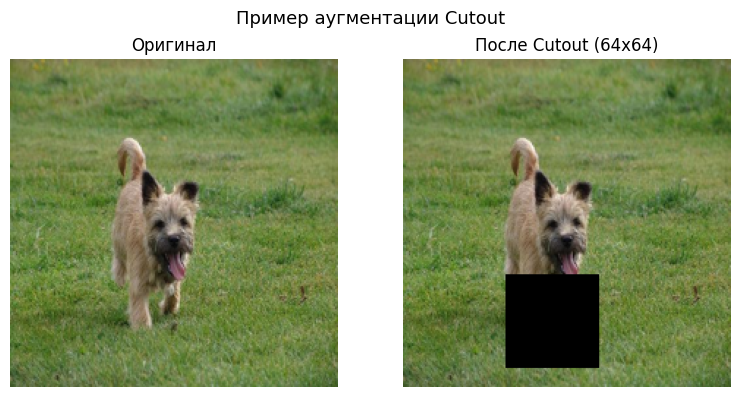

Cutout реализован


In [ ]:
class Cutout:
    """
    Cutout augmentation (DeVries & Taylor, 2017).
    Обнуляет n_holes квадратных областей размером length x length.
    Применяется только к обучающей выборке.
    """
    def __init__(self, n_holes=1, length=64):
        self.n_holes = n_holes
        self.length  = length

    def __call__(self, img):
        # img: torch.Tensor формата (C, H, W)
        h = img.size(1)
        w = img.size(2)

        mask = torch.ones((h, w), dtype=torch.float32)

        for _ in range(self.n_holes):
            cx = np.random.randint(w)
            cy = np.random.randint(h)

            x1 = max(0, cx - self.length // 2)
            x2 = min(w, cx + self.length // 2)
            y1 = max(0, cy - self.length // 2)
            y2 = min(h, cy + self.length // 2)

            mask[y1:y2, x1:x2] = 0.0

        mask = mask.unsqueeze(0).expand_as(img)
        return img * mask


# Визуализация эффекта Cutout
def show_cutout_example():
    sample_path = None
    for breed in os.listdir(f'{ROOT}/Images'):
        breed_path = f'{ROOT}/Images/{breed}'
        files = [f for f in os.listdir(breed_path) if f.endswith('.jpg')]
        if files:
            sample_path = f'{breed_path}/{files[0]}'
            break

    if not sample_path:
        return

    img = Image.open(sample_path).convert('RGB').resize((224, 224))
    to_tensor = transforms.ToTensor()
    cutout    = Cutout(n_holes=1, length=64)

    img_tensor = to_tensor(img)
    img_cutout = cutout(img_tensor.clone())

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img_tensor.permute(1, 2, 0))
    axes[0].set_title('Оригинал')
    axes[0].axis('off')
    axes[1].imshow(img_cutout.permute(1, 2, 0).clamp(0, 1))
    axes[1].set_title('После Cutout (64x64)')
    axes[1].axis('off')
    plt.suptitle('Пример аугментации Cutout', fontsize=13)
    plt.tight_layout()
    plt.savefig('/content/cutout_example.png', dpi=150, bbox_inches='tight')
    plt.show()

show_cutout_example()
print('Cutout реализован')

In [ ]:
class StanfordDogsDataset(Dataset):
    """
    Stanford Dogs Dataset.
    Читает аннотации из .mat файлов, разбивает данные в пропорции 70/15/15.
    """
    def __init__(self, root, split='train', transform=None):
        self.root      = root
        self.transform = transform

        train_mat = scipy.io.loadmat(os.path.join(root, 'lists', 'train_list.mat'))
        test_mat  = scipy.io.loadmat(os.path.join(root, 'lists', 'test_list.mat'))

        # Объединяем все данные, затем делим сами
        all_files = (
            [str(f[0][0]) for f in train_mat['file_list']] +
            [str(f[0][0]) for f in test_mat['file_list']]
        )
        all_labels = (
            [int(l[0]) - 1 for l in train_mat['labels']] +
            [int(l[0]) - 1 for l in test_mat['labels']]
        )

        # Воспроизводимое перемешивание
        rng     = np.random.RandomState(SEED)
        indices = rng.permutation(len(all_files))
        all_files  = [all_files[i]  for i in indices]
        all_labels = [all_labels[i] for i in indices]

        total     = len(all_files)
        train_end = int(0.70 * total)
        val_end   = int(0.85 * total)

        if split == 'train':
            self.files  = all_files[:train_end]
            self.labels = all_labels[:train_end]
        elif split == 'val':
            self.files  = all_files[train_end:val_end]
            self.labels = all_labels[train_end:val_end]
        else:
            self.files  = all_files[val_end:]
            self.labels = all_labels[val_end:]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, 'Images', self.files[idx])
        image    = Image.open(img_path).convert('RGB')
        label    = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label


# Параметры нормализации ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    Cutout(n_holes=1, length=64),
])

val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = StanfordDogsDataset(ROOT, split='train', transform=train_transform)
val_dataset   = StanfordDogsDataset(ROOT, split='val',   transform=val_test_transform)
test_dataset  = StanfordDogsDataset(ROOT, split='test',  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('Размер выборок:')
print(f'  Train: {len(train_dataset)}')
print(f'  Val:   {len(val_dataset)}')
print(f'  Test:  {len(test_dataset)}')

Размер выборок:
  Train: 14405
  Val:   3088
  Test:  3087


In [ ]:
class AlexNetFineTune(nn.Module):
    """
    AlexNet с предобученными весами ImageNet.
    Последний слой заменён под 120 классов.
    Используется в экспериментах A1 и A2.
    """
    def __init__(self, num_classes=120):
        super().__init__()
        self.model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
        in_features = self.model.classifier[6].in_features
        self.model.classifier[6] = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)


class AlexNetFromScratch(nn.Module):
    """
    AlexNet без предобученных весов (случайная инициализация).
    Используется в эксперименте B.
    """
    def __init__(self, num_classes=120):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x


# Проверка архитектуры
test_model  = AlexNetFineTune(NUM_CLASSES).to(DEVICE)
test_input  = torch.randn(2, 3, 224, 224).to(DEVICE)
test_output = test_model(test_input)
print(f'AlexNet проверен:')
print(f'  Вход:  {list(test_input.shape)}')
print(f'  Выход: {list(test_output.shape)}')
del test_model, test_input, test_output

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 164MB/s]


AlexNet проверен:
  Вход:  [2, 3, 224, 224]
  Выход: [2, 120]


In [ ]:
class RefinedLion(torch.optim.Optimizer):
    """
    Refined Lion Optimizer.

    Параметры:
        lr          -- learning rate (рекомендуется в 10 раз меньше, чем для Adam)
        betas       -- (beta1, beta2): beta1 для направления обновления,
                       beta2 для экспоненциального скользящего среднего момента
        weight_decay-- L2 регуляризация
        clip_value  -- ограничение значений обновления
    """
    def __init__(self, params, lr=1e-4, betas=(0.9, 0.99),
                 weight_decay=1e-4, clip_value=1.0):
        defaults = dict(lr=lr, betas=betas,
                        weight_decay=weight_decay, clip_value=clip_value)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr           = group['lr']
            beta1, beta2 = group['betas']
            wd           = group['weight_decay']
            clip         = group['clip_value']

            for p in group['params']:
                if p.grad is None:
                    continue

                grad  = p.grad
                state = self.state[p]

                if len(state) == 0:
                    state['moment'] = torch.zeros_like(p)

                moment = state['moment']

                # Основная формула Lion: направление = sign(beta1*m + (1-beta1)*g)
                update = torch.sign(beta1 * moment + (1.0 - beta1) * grad)

                # Refined: ограничиваем значения обновления
                update = torch.clamp(update, -clip, clip)

                # Weight decay
                if wd != 0.0:
                    p.mul_(1.0 - lr * wd)

                # Обновление параметров
                p.add_(update, alpha=-lr)

                # Обновление момента
                moment.mul_(beta2).add_(grad, alpha=1.0 - beta2)

        return loss


print('Refined Lion реализован')

Refined Lion реализован


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    """Один проход по обучающей выборке. Возвращает (loss, accuracy)."""
    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Оценка модели на val или test выборке. Возвращает словарь метрик."""
    model.eval()
    total_loss = 0.0
    all_preds  = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs    = model(images)
        loss       = criterion(outputs, labels)
        total_loss += loss.item()

        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    # Macro-averaged метрики
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0
    )
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))

    return {
        'loss':      total_loss / len(loader),
        'accuracy':  accuracy,
        'precision': precision,
        'recall':    recall,
        'f1':        f1,
    }


def run_experiment(model, train_loader, val_loader, test_loader,
                   optimizer, device, num_epochs, exp_name):
    """
    Полный цикл обучения с сохранением лучшей модели по Val F1.
    Возвращает метрики на тестовой выборке и историю обучения.
    """
    criterion   = nn.CrossEntropyLoss()
    model       = model.to(device)
    best_val_f1 = 0.0
    best_path   = f'/content/best_{exp_name}.pth'
    history     = []

    print(f'\n{"-"*60}')
    print(f'Эксперимент: {exp_name}')
    print(f'{"-"*60}')

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )
        val_metrics = evaluate(model, val_loader, criterion, device)
        elapsed     = time.time() - t0

        history.append({
            'epoch':      epoch,
            'train_loss': train_loss,
            'train_acc':  train_acc,
            **{f'val_{k}': v for k, v in val_metrics.items()}
        })

        print(f'Epoch {epoch:2d}/{num_epochs} | '
              f'Loss: {train_loss:.4f} | '
              f'Train Acc: {train_acc:.3f} | '
              f'Val F1: {val_metrics["f1"]:.3f} | '
              f'{elapsed:.0f}s')

        if val_metrics['f1'] > best_val_f1:
            best_val_f1 = val_metrics['f1']
            torch.save(model.state_dict(), best_path)
            print(f'          Лучшая модель сохранена (Val F1={best_val_f1:.4f})')

    # Финальная оценка на test
    model.load_state_dict(torch.load(best_path))
    test_metrics = evaluate(model, test_loader, criterion, device)

    print(f'\nФинальные метрики на TEST ({exp_name}):')
    print(f'  Precision : {test_metrics["precision"]:.4f}')
    print(f'  Recall    : {test_metrics["recall"]:.4f}')
    print(f'  F1        : {test_metrics["f1"]:.4f}')
    print(f'  Accuracy  : {test_metrics["accuracy"]:.4f}')

    return test_metrics, history


print('Функции обучения готовы')

Функции обучения готовы


In [ ]:
print('Эксперимент A1: Pretrained + Adam')

model_A1     = AlexNetFineTune(num_classes=NUM_CLASSES)
optimizer_A1 = torch.optim.Adam(
    model_A1.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

results_A1, history_A1 = run_experiment(
    model_A1, train_loader, val_loader, test_loader,
    optimizer_A1, DEVICE,
    num_epochs=NUM_EPOCHS,
    exp_name='pretrained_adam'
)

Эксперимент A1: Pretrained + Adam

------------------------------------------------------------
Эксперимент: pretrained_adam
------------------------------------------------------------
Epoch  1/15 | Loss: 2.7761 | Train Acc: 0.311 | Val F1: 0.496 | 108s
          Лучшая модель сохранена (Val F1=0.4960)
Epoch  2/15 | Loss: 1.8109 | Train Acc: 0.496 | Val F1: 0.540 | 105s
          Лучшая модель сохранена (Val F1=0.5401)
Epoch  3/15 | Loss: 1.5826 | Train Acc: 0.549 | Val F1: 0.547 | 103s
          Лучшая модель сохранена (Val F1=0.5472)
Epoch  4/15 | Loss: 1.4249 | Train Acc: 0.587 | Val F1: 0.572 | 103s
          Лучшая модель сохранена (Val F1=0.5718)
Epoch  5/15 | Loss: 1.2955 | Train Acc: 0.618 | Val F1: 0.584 | 103s
          Лучшая модель сохранена (Val F1=0.5841)
Epoch  6/15 | Loss: 1.1659 | Train Acc: 0.658 | Val F1: 0.584 | 103s
Epoch  7/15 | Loss: 1.0941 | Train Acc: 0.669 | Val F1: 0.588 | 104s
          Лучшая модель сохранена (Val F1=0.5881)
Epoch  8/15 | Loss: 0.9901 | Tr

In [ ]:
print('Эксперимент A2: Pretrained + Refined Lion')

model_A2     = AlexNetFineTune(num_classes=NUM_CLASSES)
optimizer_A2 = RefinedLion(
    model_A2.parameters(),
    lr=1e-5,
    betas=(0.9, 0.99),
    weight_decay=1e-4,
    clip_value=1.0
)

results_A2, history_A2 = run_experiment(
    model_A2, train_loader, val_loader, test_loader,
    optimizer_A2, DEVICE,
    num_epochs=NUM_EPOCHS,
    exp_name='pretrained_lion'
)

Эксперимент A2: Pretrained + Refined Lion

------------------------------------------------------------
Эксперимент: pretrained_lion
------------------------------------------------------------
Epoch  1/15 | Loss: 3.5388 | Train Acc: 0.195 | Val F1: 0.467 | 101s
          Лучшая модель сохранена (Val F1=0.4673)
Epoch  2/15 | Loss: 1.9266 | Train Acc: 0.475 | Val F1: 0.572 | 102s
          Лучшая модель сохранена (Val F1=0.5716)
Epoch  3/15 | Loss: 1.5813 | Train Acc: 0.552 | Val F1: 0.590 | 102s
          Лучшая модель сохранена (Val F1=0.5900)
Epoch  4/15 | Loss: 1.3780 | Train Acc: 0.608 | Val F1: 0.607 | 103s
          Лучшая модель сохранена (Val F1=0.6070)
Epoch  5/15 | Loss: 1.2158 | Train Acc: 0.643 | Val F1: 0.605 | 103s
Epoch  6/15 | Loss: 1.0729 | Train Acc: 0.677 | Val F1: 0.620 | 102s
          Лучшая модель сохранена (Val F1=0.6196)
Epoch  7/15 | Loss: 0.9620 | Train Acc: 0.713 | Val F1: 0.612 | 104s
Epoch  8/15 | Loss: 0.8839 | Train Acc: 0.731 | Val F1: 0.610 | 103s
Epoc

In [ ]:
print('Эксперимент B: С нуля + Adam')

model_B     = AlexNetFromScratch(num_classes=NUM_CLASSES)
optimizer_B = torch.optim.Adam(
    model_B.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

results_B, history_B = run_experiment(
    model_B, train_loader, val_loader, test_loader,
    optimizer_B, DEVICE,
    num_epochs=NUM_EPOCHS,
    exp_name='scratch_adam'
)

Эксперимент B: С нуля + Adam

------------------------------------------------------------
Эксперимент: scratch_adam
------------------------------------------------------------
Epoch  1/15 | Loss: 4.8008 | Train Acc: 0.011 | Val F1: 0.000 | 104s
          Лучшая модель сохранена (Val F1=0.0002)
Epoch  2/15 | Loss: 4.7496 | Train Acc: 0.013 | Val F1: 0.002 | 103s
          Лучшая модель сохранена (Val F1=0.0020)
Epoch  3/15 | Loss: 4.6713 | Train Acc: 0.020 | Val F1: 0.003 | 104s
          Лучшая модель сохранена (Val F1=0.0032)
Epoch  4/15 | Loss: 4.6044 | Train Acc: 0.023 | Val F1: 0.006 | 103s
          Лучшая модель сохранена (Val F1=0.0058)
Epoch  5/15 | Loss: 4.5280 | Train Acc: 0.026 | Val F1: 0.011 | 104s
          Лучшая модель сохранена (Val F1=0.0113)
Epoch  6/15 | Loss: 4.4995 | Train Acc: 0.029 | Val F1: 0.013 | 105s
          Лучшая модель сохранена (Val F1=0.0130)
Epoch  7/15 | Loss: 4.4714 | Train Acc: 0.032 | Val F1: 0.014 | 105s
          Лучшая модель сохранена (Val 

In [ ]:
print('\n' + '='*65)
print('ИТОГОВОЕ СРАВНЕНИЕ ЭКСПЕРИМЕНТОВ')
print('='*65)

df = pd.DataFrame({
    'Эксперимент': ['A1: Pretrained+Adam', 'A2: Pretrained+Lion', 'B: Scratch+Adam'],
    'Precision':   [results_A1['precision'], results_A2['precision'], results_B['precision']],
    'Recall':      [results_A1['recall'],    results_A2['recall'],    results_B['recall']],
    'F1':          [results_A1['f1'],        results_A2['f1'],        results_B['f1']],
    'Accuracy':    [results_A1['accuracy'],  results_A2['accuracy'],  results_B['accuracy']],
})

for col in ['Precision', 'Recall', 'F1', 'Accuracy']:
    df[col] = df[col].map('{:.4f}'.format)

print(df.to_string(index=False))
print('='*65)

f1_scores = [results_A1['f1'], results_A2['f1'], results_B['f1']]
names     = ['A1 (Pretrained+Adam)', 'A2 (Pretrained+Lion)', 'B (Scratch+Adam)']
best_idx  = f1_scores.index(max(f1_scores))
print(f'\nЛучший результат по F1: {names[best_idx]} (F1={max(f1_scores):.4f})')


ИТОГОВОЕ СРАВНЕНИЕ ЭКСПЕРИМЕНТОВ
        Эксперимент Precision Recall     F1 Accuracy
A1: Pretrained+Adam    0.6008 0.5876 0.5804   0.5915
A2: Pretrained+Lion    0.6128 0.6076 0.5964   0.6122
    B: Scratch+Adam    0.0399 0.0597 0.0338   0.0606

Лучший результат по F1: A2 (Pretrained+Lion) (F1=0.5964)


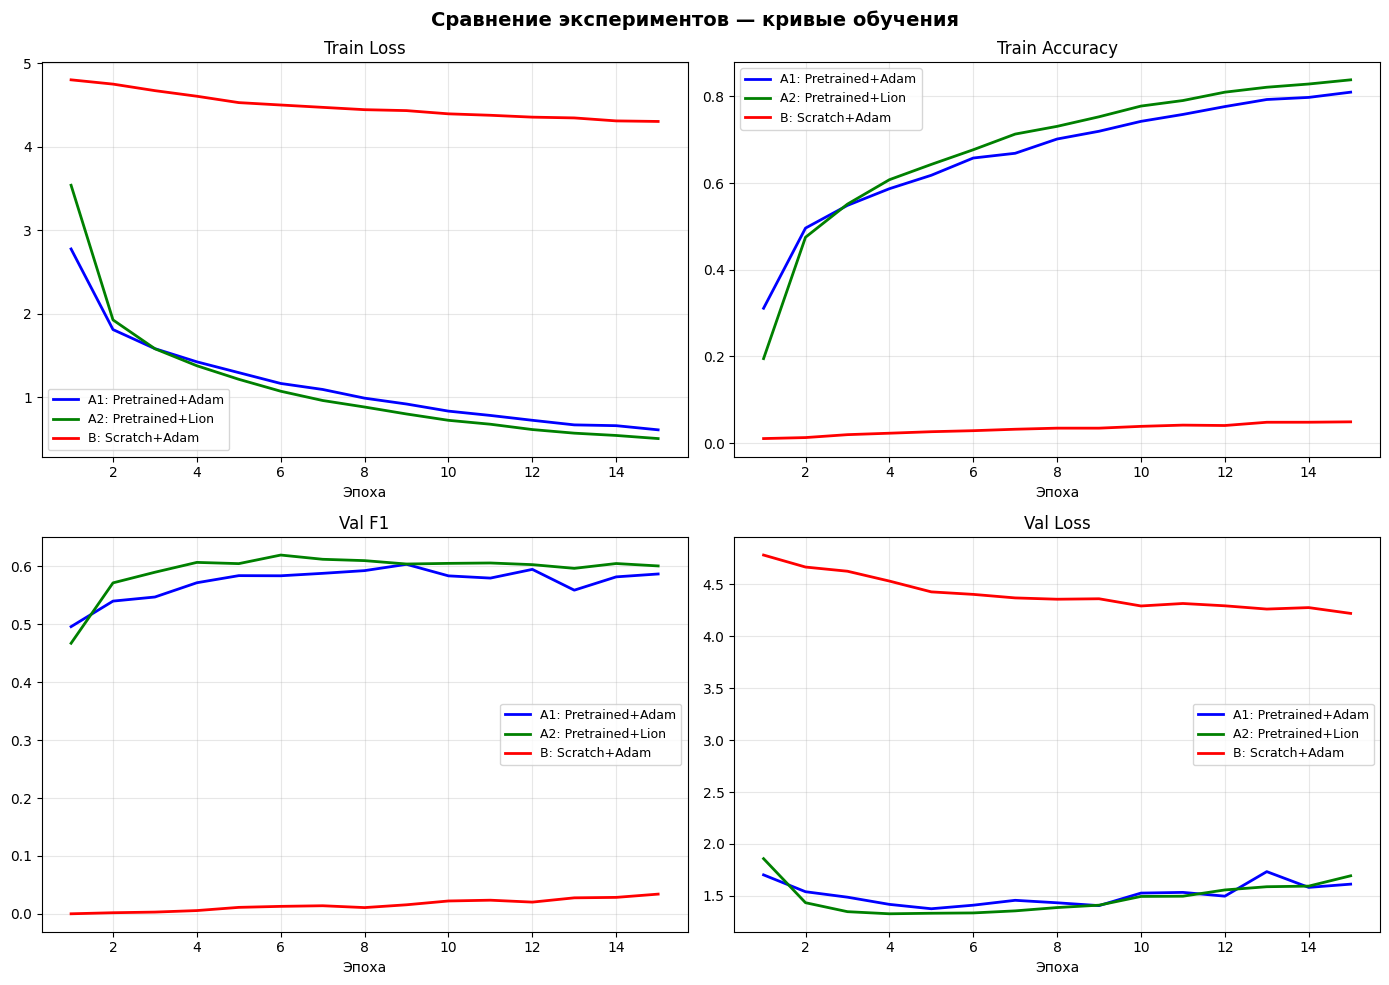

График сохранён: /content/training_curves.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Сравнение экспериментов — кривые обучения', fontsize=14, fontweight='bold')

experiments = [
    (history_A1, 'A1: Pretrained+Adam',  'blue'),
    (history_A2, 'A2: Pretrained+Lion',  'green'),
    (history_B,  'B: Scratch+Adam',      'red'),
]

metrics = [
    ('train_loss', 'Train Loss',     axes[0, 0]),
    ('train_acc',  'Train Accuracy', axes[0, 1]),
    ('val_f1',     'Val F1',         axes[1, 0]),
    ('val_loss',   'Val Loss',       axes[1, 1]),
]

for metric_key, metric_name, ax in metrics:
    for hist, label, color in experiments:
        epochs = [h['epoch']    for h in hist]
        values = [h[metric_key] for h in hist]
        ax.plot(epochs, values, label=label, color=color, linewidth=2)
    ax.set_title(metric_name)
    ax.set_xlabel('Эпоха')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: /content/training_curves.png')

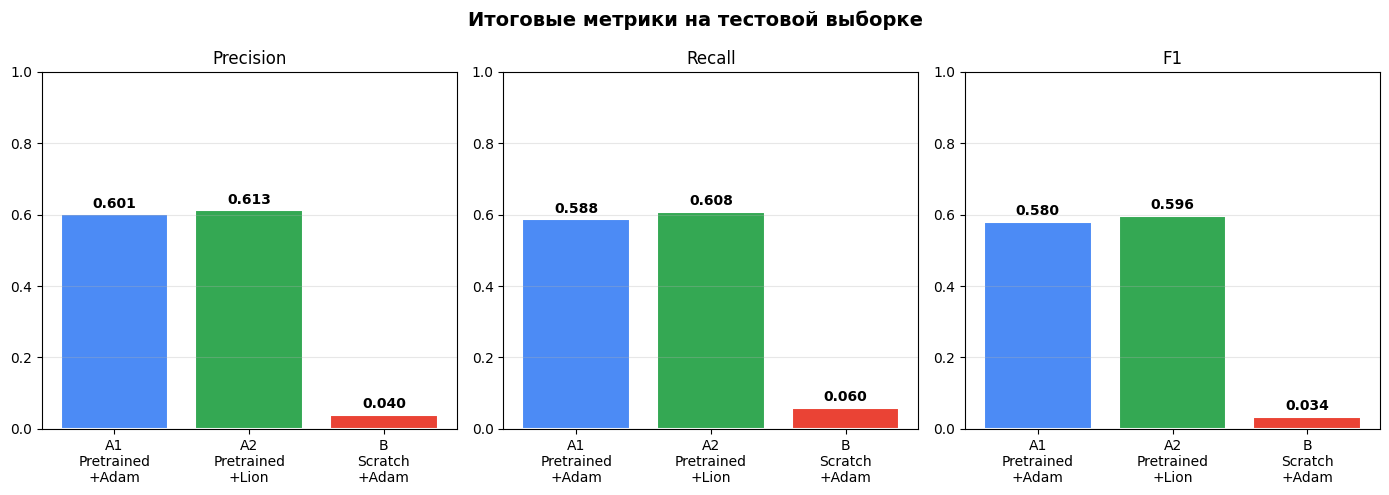

График сохранён: /content/metrics_comparison.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Итоговые метрики на тестовой выборке', fontsize=14, fontweight='bold')

exp_labels    = ['A1\nPretrained\n+Adam', 'A2\nPretrained\n+Lion', 'B\nScratch\n+Adam']
colors        = ['#4C8BF5', '#34A853', '#EA4335']
metric_names  = ['precision', 'recall', 'f1']
metric_titles = ['Precision', 'Recall', 'F1']

for i, (metric, title) in enumerate(zip(metric_names, metric_titles)):
    values = [results_A1[metric], results_A2[metric], results_B[metric]]
    bars   = axes[i].bar(exp_labels, values, color=colors, edgecolor='white', linewidth=1.5)
    axes[i].set_title(title, fontsize=12)
    axes[i].set_ylim(0, 1.0)
    axes[i].grid(True, axis='y', alpha=0.3)
    for bar, val in zip(bars, values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

plt.tight_layout()
plt.savefig('/content/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён: /content/metrics_comparison.png')